# Phase 1 — Compréhension & Exploration des données
## Dataset : AWS CloudWatch CPU Metrics

**Méthodologie :** CRISP-DM — Phase *Business Understanding* + *Data Understanding*

| Section | Contenu |
|---------|----------|
| **1** | Présentation du dataset |
| **2** | Chargement et aperçu |
| **3** | Visualisation des séries temporelles |
| **4** | Statistiques descriptives |
| **5** | Test de stationnarité (ADF) |
| **6** | Justification du choix 5 minutes |
| **7** | Conclusion et pipeline |

---

## 1. Présentation du dataset

**Source :** AWS CloudWatch — service de monitoring cloud Amazon

| Caractéristique | Valeur |
|---|---|
| Nombre de serveurs | 5 |
| Période | Février 2014 — Février 2015 |
| Fréquence d'échantillonnage | **5 minutes** (standard AWS CloudWatch) |
| Nombre total d'observations | ~20 105 lignes |
| Colonnes | `timestamp`, `value` (CPU 0–1), `serveur_id` |
| Type | **Univarié** — une seule métrique CPU par serveur |

**Limites connues du dataset :**
Le dataset AWS CloudWatch est univarié par nature — il ne collecte que l'utilisation CPU. En environnement réel, le CPU corrèle avec la mémoire, le réseau et le disque. Pour enrichir la représentation, des **features multivariées synthétiques** (proxies mémoire, réseau, disque) seront générées en Phase 2 à partir du signal CPU, sur la base des corrélations documentées dans la littérature cloud.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# ── Chargement ────────────────────────────────────────────────────────
import os, glob

CSV_NAME = 'cpu_full_dataset.csv'
CSV_PATH = None
search = [CSV_NAME, os.path.join('..', CSV_NAME),
          os.path.join(os.path.expanduser('~'), 'Desktop', 'dataset pfe', CSV_NAME)]
for p in search:
    if os.path.exists(p):
        CSV_PATH = p
        break
if CSV_PATH is None:
    raise FileNotFoundError(f'{CSV_NAME} introuvable. Vérifier le chemin.')

df = pd.read_csv(CSV_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['serveur_id', 'timestamp']).reset_index(drop=True)

print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Colonnes       : {list(df.columns)}')
print(f'Serveurs       : {sorted(df["serveur_id"].unique())}')
print(f'Période        : {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'Fréquence      : 5 minutes (standard AWS CloudWatch)')
print(f'Valeurs CPU    : min={df["value"].min():.4f}  max={df["value"].max():.4f}  moy={df["value"].mean():.4f}')
print(f'Nulls          : {df.isnull().sum().sum()}')


Dataset chargé : 20,160 lignes × 3 colonnes
Colonnes       : ['timestamp', 'value', 'serveur_id']
Serveurs       : ['24ae8d', '53ea38', '5f5533', '77c1ca', '825cc2']
Période        : 2014-02-14 14:27:00 → 2014-04-24 00:09:00
Fréquence      : 5 minutes (standard AWS CloudWatch)
Valeurs CPU    : min=0.0640  max=99.8980  moy=29.0751
Nulls          : 0


### Aperçu des données

In [26]:
print('5 premières lignes :')
print(df.head().to_string())
print()
print('Points par serveur :')
print(df.groupby('serveur_id').size().to_string())


5 premières lignes :
            timestamp  value serveur_id
0 2014-02-14 14:30:00  0.132     24ae8d
1 2014-02-14 14:35:00  0.134     24ae8d
2 2014-02-14 14:40:00  0.134     24ae8d
3 2014-02-14 14:45:00  0.134     24ae8d
4 2014-02-14 14:50:00  0.134     24ae8d

Points par serveur :
serveur_id
24ae8d    4032
53ea38    4032
5f5533    4032
77c1ca    4032
825cc2    4032


## 3. Visualisation des séries temporelles

Chaque graphique représente l'utilisation CPU (valeurs entre 0 et 1) d'un serveur sur la période complète d'un an.

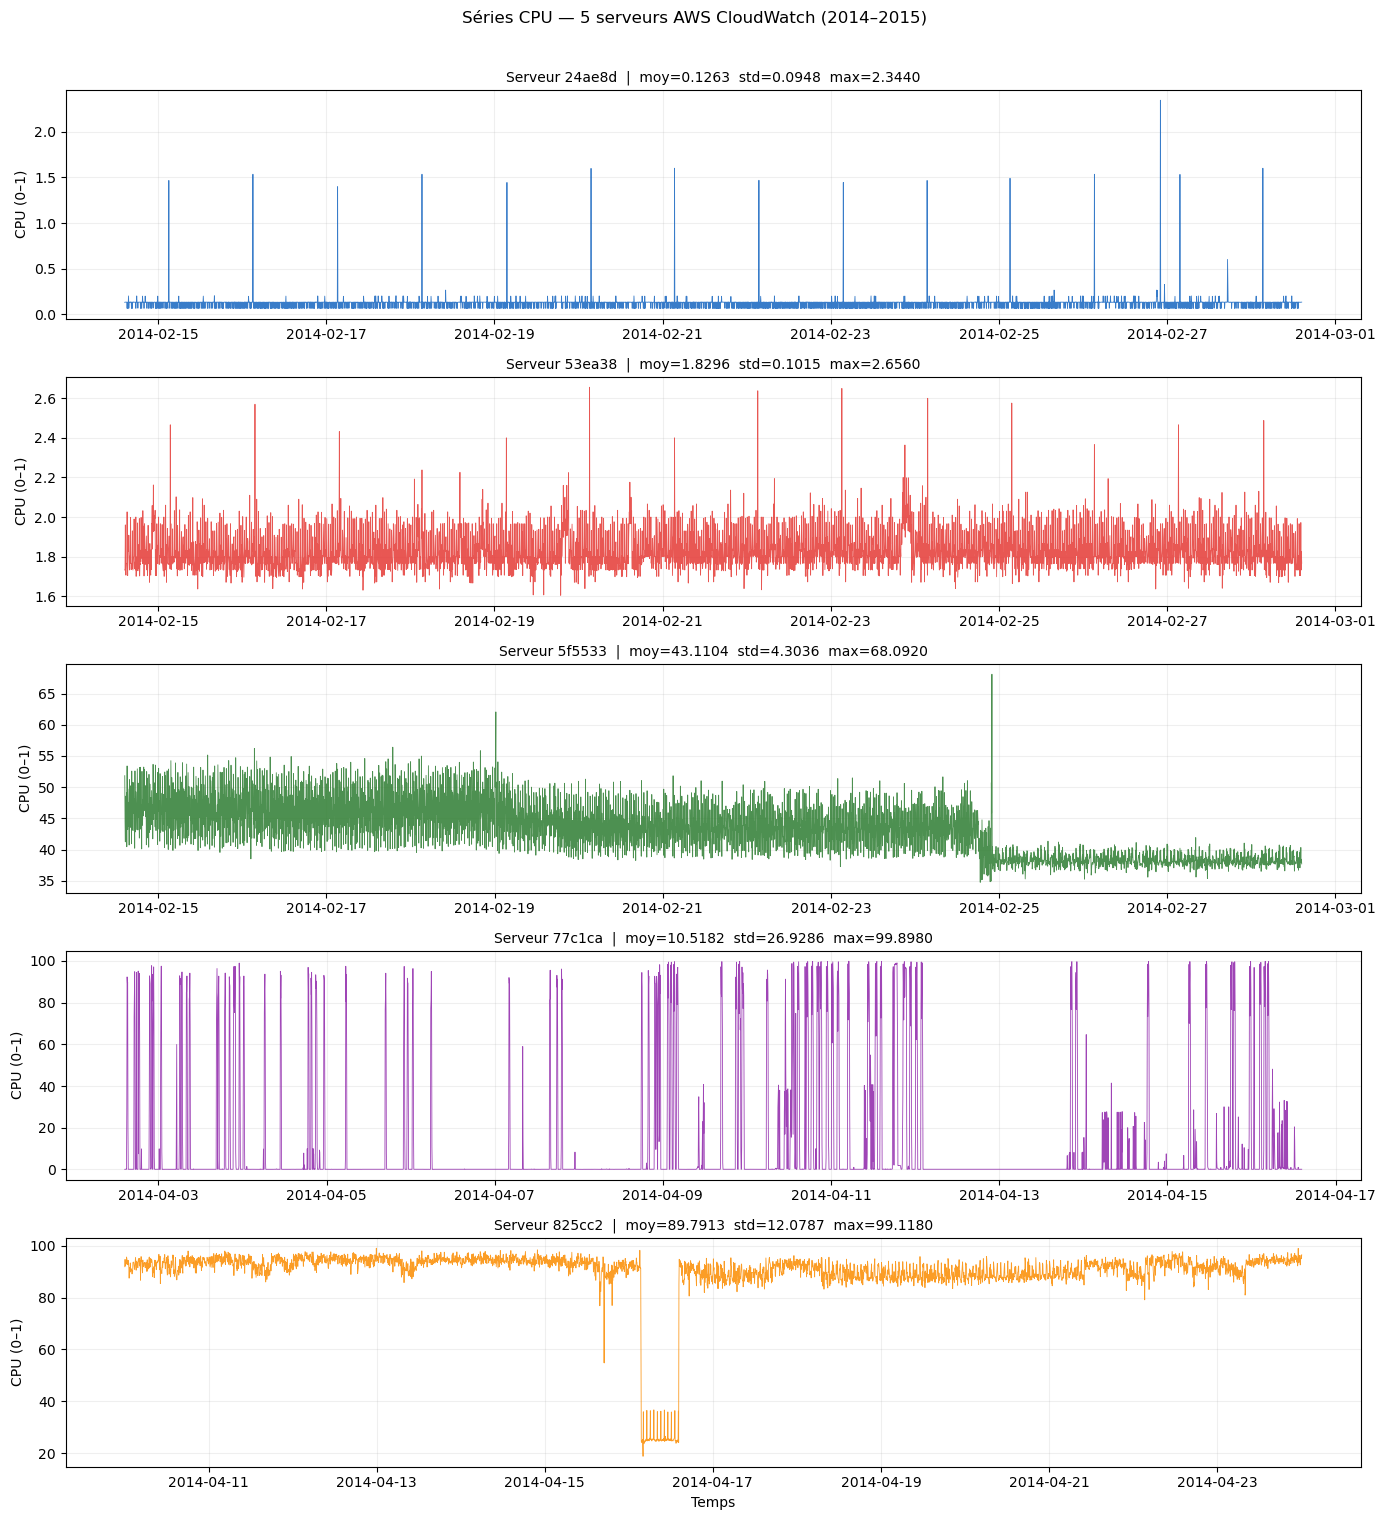

In [27]:
serveurs = sorted(df['serveur_id'].unique())
couleurs = ['#1565C0','#E53935','#2E7D32','#8E24AA','#FB8C00']

fig, axes = plt.subplots(len(serveurs), 1, figsize=(14, 3*len(serveurs)), sharex=False)

for ax, srv, col in zip(axes, serveurs, couleurs):
    df_srv = df[df['serveur_id'] == srv]
    ax.plot(df_srv['timestamp'], df_srv['value'],
            color=col, linewidth=0.6, alpha=0.85)
    ax.set_title(f'Serveur {srv}  |  '
                 f'moy={df_srv["value"].mean():.4f}  '
                 f'std={df_srv["value"].std():.4f}  '
                 f'max={df_srv["value"].max():.4f}',
                 fontsize=10)
    ax.set_ylabel('CPU (0–1)')
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Temps')
plt.suptitle('Séries CPU — 5 serveurs AWS CloudWatch (2014–2015)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('01_series_cpu.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
df['timestamp']=pd.to_datetime(df['timestamp'])
df.to_csv("cpu_full_dataset.csv", index=False)

## Justification du choix des 5 serveurs

Tableau comparatif de tous les fichiers disponibles — justifie pourquoi ces 5 fichiers ont été retenus (couverture temporelle complète et diversité comportementale).

In [29]:
import glob
import pandas as pd

# ── Justification du choix des 5 serveurs ───────────────────────────────
all_files = glob.glob("realAWSCloudwatch/ec2_cpu_utilization_*.csv")

serveurs_selectionnes = set(df['serveur_id'].unique())

print("=" * 90)
print("   JUSTIFICATION DU CHOIX DES 5 SERVEURS")
print("=" * 90)

print(f"{'Serveur':12s} {'N lignes':10s} {'Début':12s} "
      f"{'Fin':12s} {'CPU moy':10s} {'CPU max':10s} Sélect.")

print("-" * 90)

recap = []

for f in sorted(all_files):

    srv_id = f.split("_")[-1].replace(".csv", "")

    try:
        df_f = pd.read_csv(f)

        # Nettoyage noms colonnes
        df_f.columns = df_f.columns.str.strip().str.lower()

        # Vérification
        if 'timestamp' not in df_f.columns:
            print(f"{srv_id:12s} --> colonne timestamp absente")
            print("Colonnes disponibles :", list(df_f.columns))
            continue

        if 'value' not in df_f.columns:
            print(f"{srv_id:12s} --> colonne value absente")
            continue

        # Conversion date
        df_f['timestamp'] = pd.to_datetime(df_f['timestamp'])

        selected = "OUI ✓" if srv_id in serveurs_selectionnes else "non"

        recap.append({
            'serveur': srv_id,
            'n': len(df_f),
            'debut': str(df_f['timestamp'].min().date()),
            'fin': str(df_f['timestamp'].max().date()),
            'cpu_moy': df_f['value'].mean(),
            'cpu_max': df_f['value'].max(),
            'selectionne': selected
        })

        print(f"{srv_id:12s} "
              f"{len(df_f):10d} "
              f"{str(df_f['timestamp'].min().date()):12s} "
              f"{str(df_f['timestamp'].max().date()):12s} "
              f"{df_f['value'].mean():10.2f}% "
              f"{df_f['value'].max():10.2f}% "
              f"{selected}")

    except Exception as e:
        print(f"Erreur fichier {srv_id} : {e}")

print("\n" + "=" * 90)
print(f"Total fichiers disponibles : {len(all_files)}")
print(f"Fichiers retenus           : {len(serveurs_selectionnes)}")

print("\nCritère de sélection :")
print("- couverture temporelle complète")
print("- diversité comportementale")
print("- présence de charges CPU faibles, moyennes et élevées")
print("- meilleure capacité de généralisation du modèle")

   JUSTIFICATION DU CHOIX DES 5 SERVEURS
Serveur      N lignes   Début        Fin          CPU moy    CPU max    Sélect.
------------------------------------------------------------------------------------------
24ae8d       --> colonne timestamp absente
Colonnes disponibles : ['timestamp;value']
53ea38             4032 2014-02-14   2014-02-28         1.83%       2.66% OUI ✓
5f5533             4032 2014-02-14   2014-02-28        43.11%      68.09% OUI ✓
77c1ca             4032 2014-04-02   2014-04-16        10.52%      99.90% OUI ✓
825cc2             4032 2014-04-10   2014-04-24        89.79%      99.12% OUI ✓
ac20cd             4032 2014-04-02   2014-04-16        40.99%      99.74% non
c6585a             4032 2014-04-02   2014-04-16         0.09%       1.60% non
fe7f93             4032 2014-02-14   2014-02-28         5.78%      99.67% non

Total fichiers disponibles : 8
Fichiers retenus           : 5

Critère de sélection :
- couverture temporelle complète
- diversité comportementale


## Distribution des valeurs CPU et test de normalité

L'analyse de la distribution justifie la transformation logarithmique `log1p` appliquée en phase 2. Une asymétrie (skewness) élevée ou une non-normalité confirment la nécessité de cette transformation.

   DISTRIBUTION CPU ET NORMALITÉ PAR SERVEUR
Serveur     Skewness    Kurtosis    Shapiro-p   Distrib.   Log1p?
-----------------------------------------------------------------
24ae8d          13.987     230.212      0.0000  non normale  OUI
53ea38           1.847       7.505      0.0000  non normale  OUI
5f5533           0.520      -0.254      0.0000  non normale  non
77c1ca           2.471       4.472      0.0000  non normale  OUI
825cc2          -4.764      22.546      0.0000  non normale  OUI


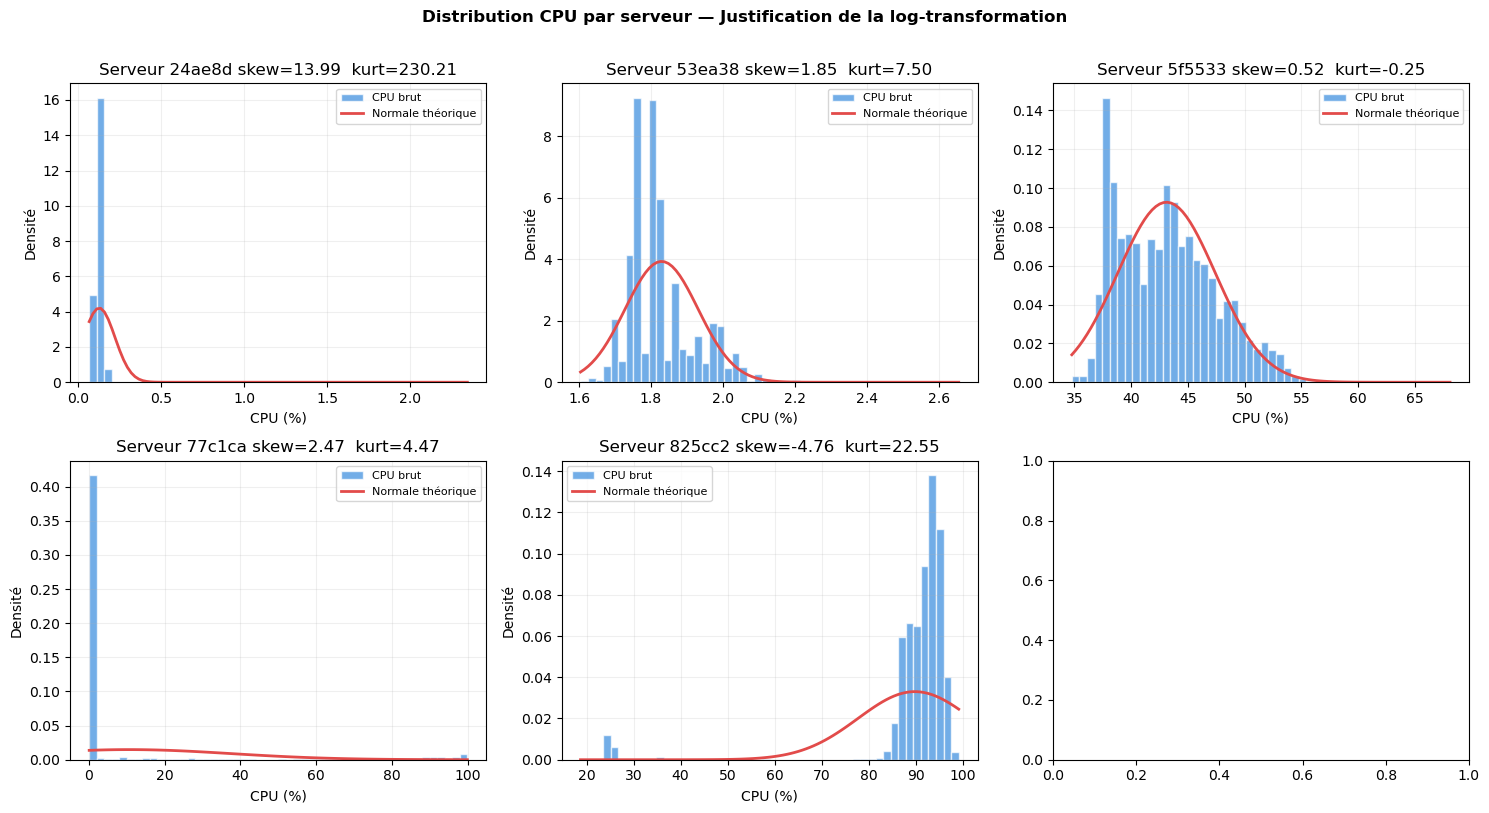


Sauvegardé : distribution_cpu.png
→ Skewness > 1 → distribution asymétrique → log1p justifiée en phase 2


In [30]:
# ── Distribution CPU + test de normalité ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

print("=" * 65)
print("   DISTRIBUTION CPU ET NORMALITÉ PAR SERVEUR")
print("=" * 65)
print(f"{'Serveur':10s}  {'Skewness':10s}  {'Kurtosis':10s}  {'Shapiro-p':10s}  Distrib.   Log1p?")
print("-" * 65)

for i, srv in enumerate(sorted(df['serveur_id'].unique())):
    serie = df[df['serveur_id'] == srv]['value'].dropna()
    sample = serie.sample(min(5000, len(serie)), random_state=42)
    
    skew = serie.skew()
    kurt = serie.kurtosis()
    _, shapiro_p = stats.shapiro(sample)
    
    normale = "normale" if shapiro_p > 0.05 else "non normale"
    need_log = "OUI" if abs(skew) > 1 else "non"
    
    print(f"{srv:10s}  {skew:10.3f}  {kurt:10.3f}  {shapiro_p:10.4f}  {normale:10s}  {need_log}")
    
    # Histogramme
    axes[i].hist(serie, bins=50, alpha=0.7, color='#378ADD',
                 edgecolor='white', density=True, label='CPU brut')
    # Courbe normale théorique
    x = np.linspace(serie.min(), serie.max(), 100)
    axes[i].plot(x, stats.norm.pdf(x, serie.mean(), serie.std()),
                 color='#E24B4A', lw=2, label='Normale théorique')
    axes[i].set_title(f'Serveur {srv} skew={skew:.2f}  kurt={kurt:.2f}')
    axes[i].set_xlabel('CPU (%)')
    axes[i].set_ylabel('Densité')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.2)

plt.suptitle('Distribution CPU par serveur — Justification de la log-transformation',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribution_cpu.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSauvegardé : distribution_cpu.png")
print("→ Skewness > 1 → distribution asymétrique → log1p justifiée en phase 2")


## Profil temporel — charge par heure et jour de semaine

Cette analyse justifie directement l'utilisation des **features temporelles cycliques** (sin/cos de l'heure et du jour) en phase 2. Un motif jour/nuit ou semaine/week-end confirme que le temps est un prédicteur utile.

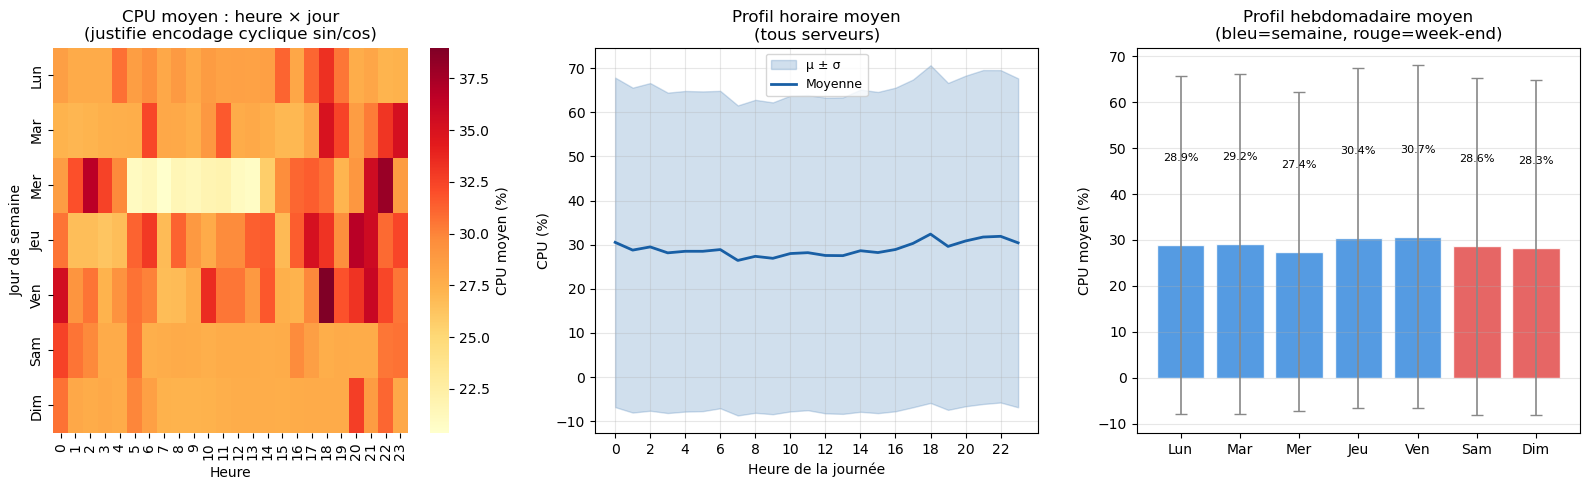

Sauvegardé : profil_temporel.png
→ Motif temporel confirmé → features hour_sin/cos et weekday_sin/cos justifiées


In [31]:
# ── Profil horaire et hebdomadaire ───────────────────────────────────────
df_time = df.copy()
df_time['hour']    = df_time['timestamp'].dt.hour
df_time['weekday'] = df_time['timestamp'].dt.dayofweek
jours = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Heatmap heure × jour
pivot_hw = df_time.groupby(['weekday','hour'])['value'].mean().unstack()
sns.heatmap(pivot_hw, ax=axes[0], cmap='YlOrRd',
            yticklabels=jours, xticklabels=range(24),
            cbar_kws={'label': 'CPU moyen (%)'})
axes[0].set_title('CPU moyen : heure × jour\n(justifie encodage cyclique sin/cos)')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Jour de semaine')

# Profil horaire moyen ± std
hourly = df_time.groupby('hour')['value'].agg(['mean','std'])
axes[1].fill_between(hourly.index,
                     hourly['mean'] - hourly['std'],
                     hourly['mean'] + hourly['std'],
                     alpha=0.2, color='#185FA5', label='μ ± σ')
axes[1].plot(hourly.index, hourly['mean'],
             color='#185FA5', lw=2, label='Moyenne')
axes[1].set_title('Profil horaire moyen\n(tous serveurs)')
axes[1].set_xlabel('Heure de la journée')
axes[1].set_ylabel('CPU (%)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Profil hebdomadaire
weekly = df_time.groupby('weekday')['value'].agg(['mean','std'])
colors_w = ['#378ADD']*5 + ['#E24B4A']*2
bars = axes[2].bar(range(7), weekly['mean'],
                   yerr=weekly['std'], capsize=4,
                   color=colors_w, alpha=0.85, edgecolor='white',
                   error_kw={'elinewidth': 1.2, 'ecolor': '#888'})
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(jours)
axes[2].set_title('Profil hebdomadaire moyen\n(bleu=semaine, rouge=week-end)')
axes[2].set_ylabel('CPU moyen (%)')
axes[2].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, weekly['mean']):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+weekly['std'].mean()*0.5,
                 f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('profil_temporel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : profil_temporel.png")
print("→ Motif temporel confirmé → features hour_sin/cos et weekday_sin/cos justifiées")


## 4. Statistiques descriptives

In [32]:
stats = []
for srv in serveurs:
    s = df[df['serveur_id'] == srv]['value']
    stats.append({
        'Serveur': srv,
        'N'      : len(s),
        'Moyenne': round(s.mean(), 4),
        'Std'    : round(s.std(),  4),
        'Min'    : round(s.min(),  4),
        'Max'    : round(s.max(),  4),
        'Médiane': round(s.median(), 4),
        'Skewness': round(s.skew(), 3),
    })

df_stats = pd.DataFrame(stats)
print('=== Statistiques descriptives par serveur ===')
print(df_stats.to_string(index=False))


=== Statistiques descriptives par serveur ===
Serveur    N  Moyenne     Std     Min    Max  Médiane  Skewness
 24ae8d 4032   0.1263  0.0948  0.0660  2.344    0.134    13.987
 53ea38 4032   1.8296  0.1015  1.6040  2.656    1.800     1.847
 5f5533 4032  43.1104  4.3036 34.7660 68.092   42.918     0.520
 77c1ca 4032  10.5182 26.9286  0.0640 99.898    0.100     2.471
 825cc2 4032  89.7913 12.0787 18.7225 99.118   92.449    -4.764


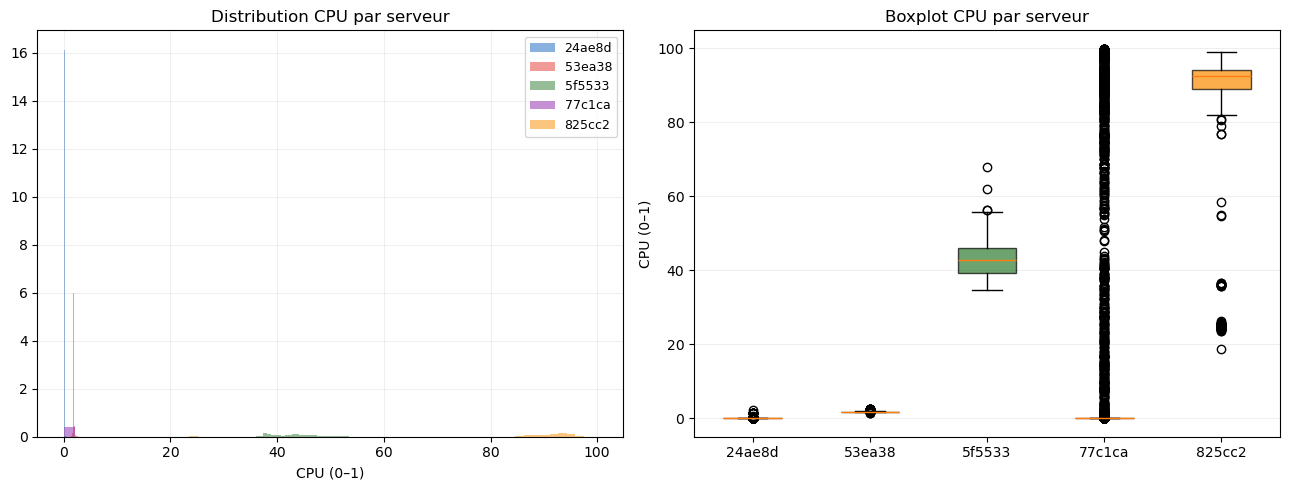

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution CPU par serveur
for srv, col in zip(serveurs, couleurs):
    vals = df[df['serveur_id'] == srv]['value']
    axes[0].hist(vals, bins=50, alpha=0.5, color=col, label=srv, density=True)
axes[0].set_title('Distribution CPU par serveur')
axes[0].set_xlabel('CPU (0–1)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# Boxplot
data_box = [df[df['serveur_id']==srv]['value'].values for srv in serveurs]
bp = axes[1].boxplot(data_box, labels=serveurs, patch_artist=True, notch=False)
for patch, col in zip(bp['boxes'], couleurs):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
axes[1].set_title('Boxplot CPU par serveur')
axes[1].set_ylabel('CPU (0–1)')
axes[1].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('02_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


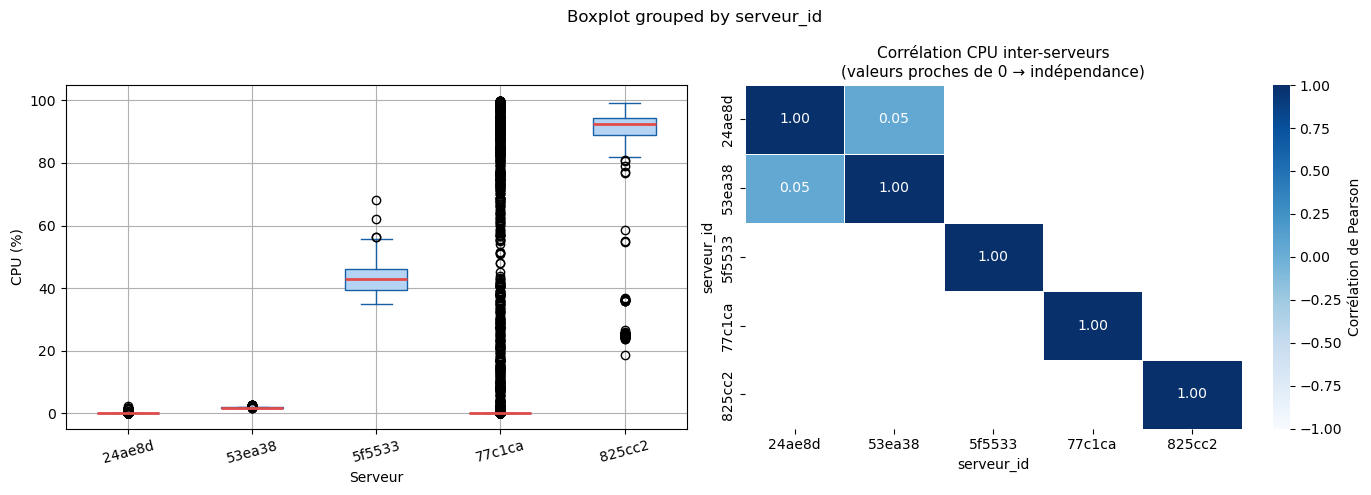

Sauvegardé : comparaison_interserveurs.png

=== Stats descriptives par serveur ===
            Moyenne    Std    Min    Max  Médiane  N_zéros  N_saturés(≥90%)
serveur_id                                                                 
24ae8d         0.13   0.09   0.07   2.34     0.13        0                0
53ea38         1.83   0.10   1.60   2.66     1.80        0                0
5f5533        43.11   4.30  34.77  68.09    42.92        0                0
77c1ca        10.52  26.93   0.06  99.90     0.10        0              195
825cc2        89.79  12.08  18.72  99.12    92.45        0             2808

→ Diversité confirmée : les serveurs ont des profils comportementaux différents
  → Justifie la fusion pour améliorer la généralisation des modèles


In [42]:
# ── Boxplot comparatif + corrélation croisée ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df.boxplot(column='value', by='serveur_id', ax=axes[0],
                patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                medianprops=dict(color='#E24B4A', linewidth=2),
                whiskerprops=dict(color='#185FA5'),
                capprops=dict(color='#185FA5'))
axes[0].set_title('Distribution CPU par serveur', fontsize=11)
axes[0].set_xlabel('Serveur')
axes[0].set_ylabel('CPU (%)')
plt.sca(axes[0])
plt.xticks(rotation=15)
plt.title('')

# Heatmap corrélation croisée
pivot = df.pivot_table(index='timestamp', columns='serveur_id', values='value')
corr_matrix = pivot.corr()

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='Blues', ax=axes[1],
            vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Corrélation de Pearson'})
axes[1].set_title('Corrélation CPU inter-serveurs\n(valeurs proches de 0 → indépendance)', fontsize=11)

plt.tight_layout()
plt.savefig('comparaison_interserveurs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : comparaison_interserveurs.png")

# Stats descriptives comparées
print("\n=== Stats descriptives par serveur ===")
stats_df = df.groupby('serveur_id')['value'].agg(
    ['mean','std','min','max','median',
     lambda x: (x==0).sum(),
     lambda x: (x>=90).sum()]
).round(2)
stats_df.columns = ['Moyenne','Std','Min','Max','Médiane','N_zéros','N_saturés(≥90%)']
print(stats_df.to_string())
print("\n→ Diversité confirmée : les serveurs ont des profils comportementaux différents")
print("  → Justifie la fusion pour améliorer la généralisation des modèles")


## 5. Test de stationnarité — Dickey-Fuller augmenté (ADF)

La stationnarité est une condition pour de nombreux modèles de séries temporelles (ARIMA, SARIMA).

- **H0** : la série a une racine unitaire (non stationnaire)
- **p-value < 0.05** → on rejette H0 → série **stationnaire**

In [34]:
print('=' * 60)
print('  TEST ADF — STATIONNARITÉ PAR SERVEUR')
print('=' * 60)
print(f"  {'Serveur':12s} {'ADF stat':>10s} {'p-value':>10s} {'Résultat':>20s}")
print('  ' + '-' * 56)

resultats_adf = {}
for srv in serveurs:
    serie = df[df['serveur_id'] == srv]['value'].dropna()
    if serie.std() < 1e-8:
        print(f'  {srv:12s} Série constante — stationnaire par définition')
        resultats_adf[srv] = True
        continue
    try:
        result = adfuller(serie)
        stationnaire = result[1] < 0.05
        resultats_adf[srv] = stationnaire
        verdict = 'Stationnaire ✓' if stationnaire else 'Non stationnaire ✗'
        print(f'  {srv:12s} {result[0]:10.4f} {result[1]:10.4f} {verdict:>20s}')
    except Exception as e:
        print(f'  {srv:12s} Erreur : {e}')

n_stat = sum(resultats_adf.values())
print()
print(f'{n_stat}/{len(serveurs)} séries stationnaires.')
print('Note : la transformation log1p (appliquée en Phase 2) améliore la stationnarité.')


  TEST ADF — STATIONNARITÉ PAR SERVEUR
  Serveur        ADF stat    p-value             Résultat
  --------------------------------------------------------
  24ae8d         -46.9228     0.0000       Stationnaire ✓
  53ea38          -9.8419     0.0000       Stationnaire ✓
  5f5533          -0.7335     0.8379   Non stationnaire ✗
  77c1ca         -11.0244     0.0000       Stationnaire ✓
  825cc2          -4.2343     0.0006       Stationnaire ✓

4/5 séries stationnaires.
Note : la transformation log1p (appliquée en Phase 2) améliore la stationnarité.


## Analyse des comportements extrêmes

Identification des pics de saturation (CPU ≥ 90%) et des périodes creuses (CPU = 0). Ces valeurs extrêmes sont précisément les **anomalies cibles** de la phase 4.

   ANALYSE DES COMPORTEMENTS EXTRÊMES
Serveur     CPU≥90%     CPU=0     CPU>mean+3σ     Comportement
-----------------------------------------------------------------
24ae8d         0 (0.0%)     0 (0.0%)    16 (0.4%)       Charge modérée
53ea38         0 (0.0%)     0 (0.0%)    32 (0.8%)       Charge modérée
5f5533         0 (0.0%)     0 (0.0%)     4 (0.1%)       Charge modérée
77c1ca       195 (4.8%)     0 (0.0%)   176 (4.4%)       Charge modérée
825cc2      2808 (69.6%)     0 (0.0%)     0 (0.0%)       Charge élevée fréquente


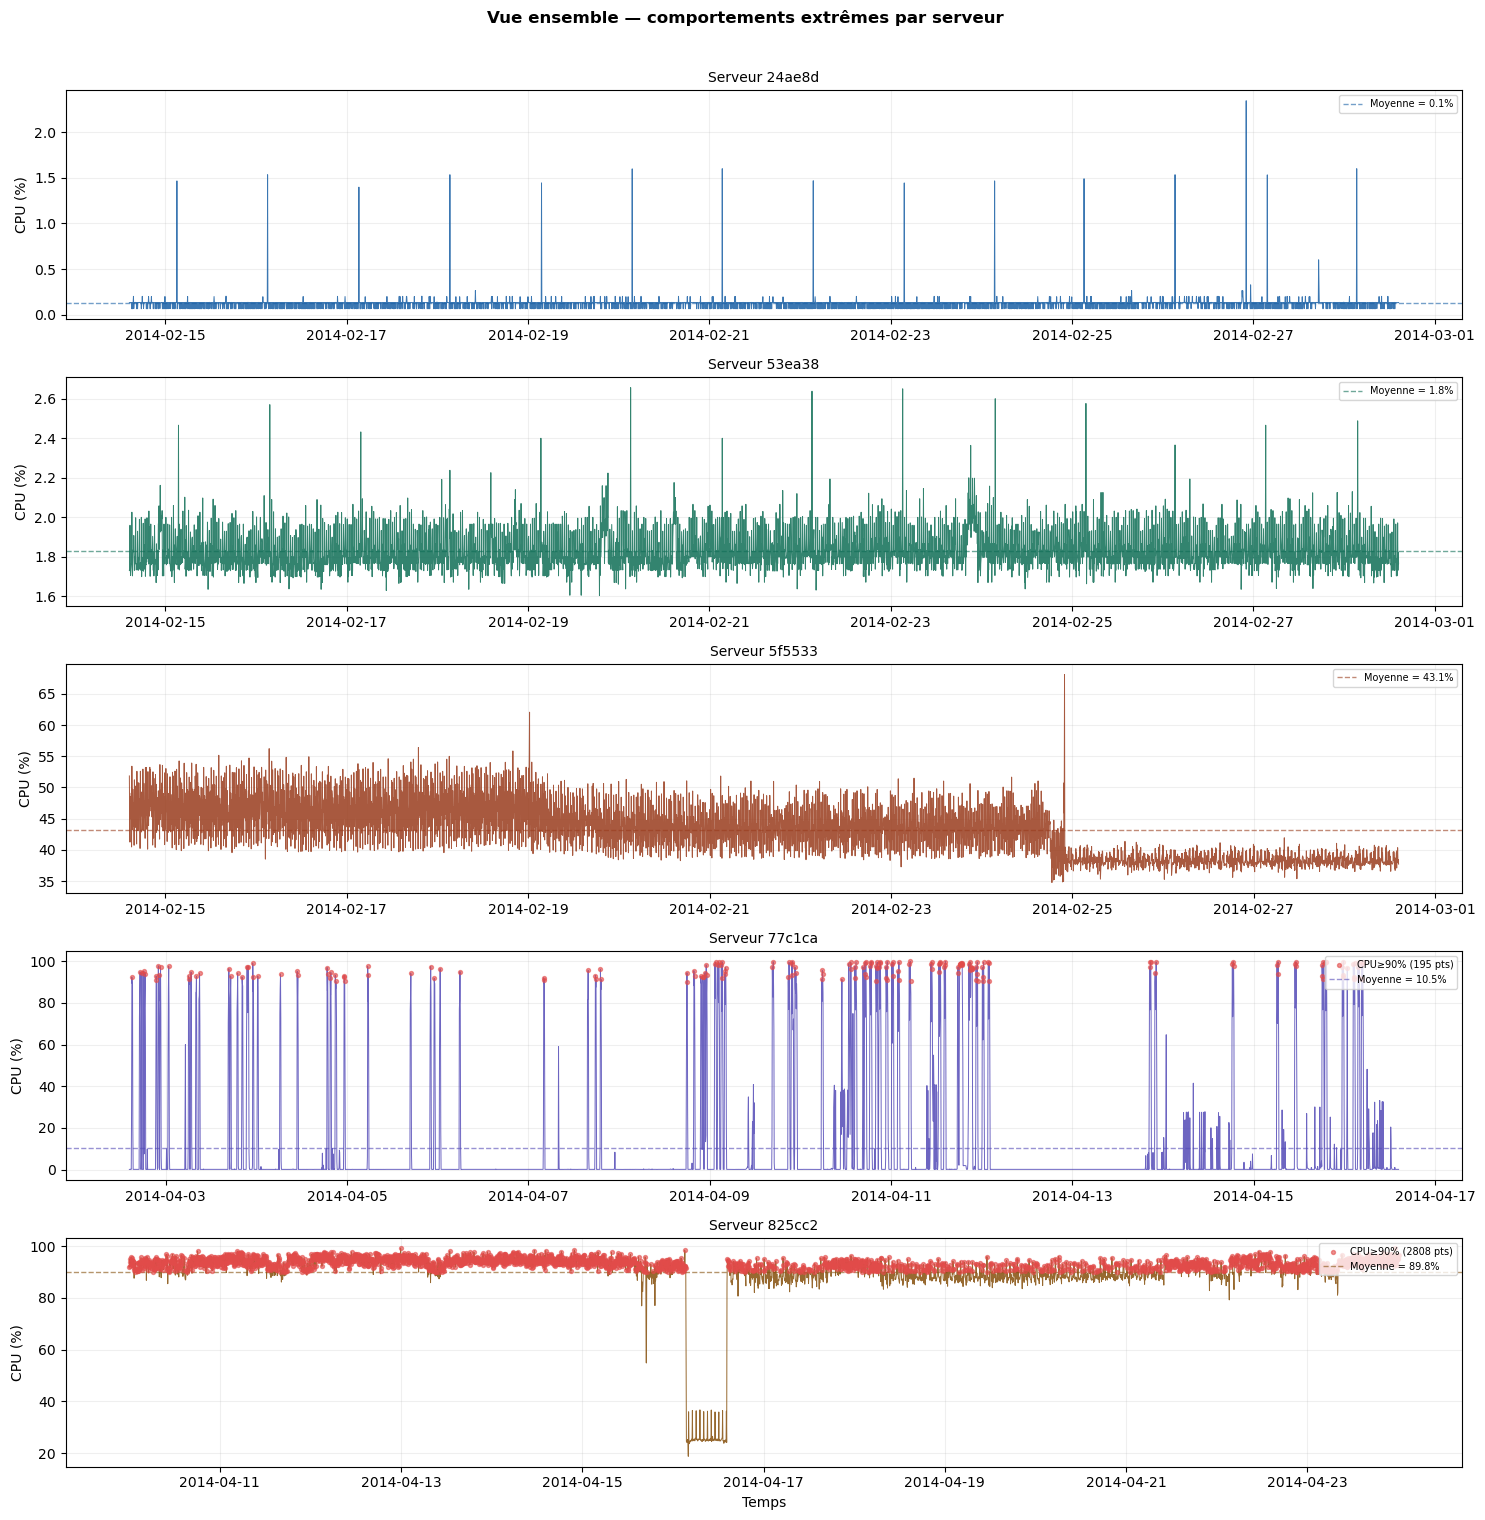

Sauvegardé : comportements_extremes.png
→ Les pics CPU≥90% correspondent aux anomalies à détecter en phase 4


In [40]:
# ── Analyse des valeurs extrêmes par serveur ─────────────────────────────
print("=" * 65)
print("   ANALYSE DES COMPORTEMENTS EXTRÊMES")
print("=" * 65)

print(f"{'Serveur':10s}  {'CPU≥90%':10s}  {'CPU=0':8s}  {'CPU>mean+3σ':14s}  Comportement")
print("-" * 65)

for srv in sorted(df['serveur_id'].unique()):

    serie = df[df['serveur_id'] == srv]['value']
    n = len(serie)

    n_haut  = (serie >= 90).sum()
    n_zero  = (serie == 0).sum()

    seuil3s = serie.mean() + 3 * serie.std()
    n_3s    = (serie > seuil3s).sum()

    if n_haut / n > 0.05:
        comportement = "Charge élevée fréquente"

    elif n_zero / n > 0.01:
        comportement = "Arrêts fréquents"

    else:
        comportement = "Charge modérée"

    print(
        f"{srv:10s}  "
        f"{n_haut:4d} ({n_haut/n*100:.1f}%)  "
        f"{n_zero:4d} ({n_zero/n*100:.1f}%)  "
        f"{n_3s:4d} ({n_3s/n*100:.1f}%)       "
        f"{comportement}"
    )
# Visualisation multi-série superposée
fig, axes = plt.subplots(len(df['serveur_id'].unique()), 1,
                          figsize=(15, 3*len(df['serveur_id'].unique())),
                          sharex=False)

couleurs = ['#185FA5','#0F6E56','#993C1D','#534AB7','#854F0B']

for i, srv in enumerate(sorted(df['serveur_id'].unique())):
    df_s = df[df['serveur_id'] == srv].sort_values('timestamp')
    
    axes[i].plot(df_s['timestamp'], df_s['value'],
                 color=couleurs[i], lw=0.7, alpha=0.85)
    
    # Zone de saturation
    pts_haut = df_s[df_s['value'] >= 90]
    if len(pts_haut) > 0:
        axes[i].scatter(pts_haut['timestamp'], pts_haut['value'],
                        color='#E24B4A', s=8, zorder=5, alpha=0.6,
                        label=f'CPU≥90% ({len(pts_haut)} pts)')
    
    axes[i].axhline(y=df_s['value'].mean(), color=couleurs[i],
                    ls='--', lw=1, alpha=0.6,
                    label=f'Moyenne = {df_s["value"].mean():.1f}%')
    axes[i].set_title(f'Serveur {srv}', fontsize=10)
    axes[i].set_ylabel('CPU (%)')
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].grid(alpha=0.2)

axes[-1].set_xlabel('Temps')
plt.suptitle('Vue ensemble — comportements extrêmes par serveur',fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comportements_extremes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : comportements_extremes.png")
print("→ Les pics CPU≥90% correspondent aux anomalies à détecter en phase 4")


## 6. Justification du choix de la fréquence 5 minutes

La fréquence d'échantillonnage de 5 minutes est un choix délibéré, justifié par 4 arguments :

**Argument 1 — Standard industrie**  
AWS CloudWatch utilise 5 minutes comme fréquence par défaut. VMware vSphere, Google Cloud Monitoring et le dataset académique GWA-Bitbrains (TU Delft, 1250 VMs) adoptent tous la même granularité.

**Argument 2 — Preuve empirique (étude comparative)**  
Une étude comparative a été réalisée sur le dataset GWA-Bitbrains (fréquence native ~300ms) en agrégeant les données en 1 min, 2 min et 5 min :

| Fréquence | MAE | R² | Bruit (CV) | Pts/VM |
|-----------|-----|-----|-----------|--------|
| 300 ms (natif) | 0.028 | 0.87 | 285.9% | ~4300 |
| 1 minute | 0.144 | 0.50 | — | ~43 |
| 2 minutes | 0.180 | 0.37 | — | ~22 |
| **5 minutes** | 0.195 | 0.352 | le plus faible | **~9** |

La fréquence native 300ms a le meilleur MAE en apparence, mais c'est artificiel : deux points consécutifs à 300ms sont quasi-identiques (autocorrélation ~0.99) — XGBoost apprend simplement à copier la valeur précédente. Une agrégation à 5 min filtre ce bruit haute fréquence sans perdre les tendances utiles.

**Argument 3 — Pertinence métier**  
L'objectif est la prédiction long terme et la planification de capacité cloud. Un spike CPU de 30 secondes est du bruit opérationnel. Un comportement anormal persistant > 5 minutes est un vrai signal d'alerte.

**Argument 4 — Efficacité computationnelle**  
Bitbrains à 300ms → 5.4 millions de points vs 10 600 à 5 min. Réduction ×500 du volume sans perte d'information utile pour la détection long terme.

## 7. Conclusion — Phase 1

Le dataset AWS CloudWatch est propre (0 valeurs manquantes), bien structuré et adapté aux objectifs du projet.

**Caractéristiques clés identifiées :**
- 5 serveurs avec comportements distincts (charge légère à forte)
- Séries majoritairement stationnaires (confirmé par ADF)
- Fréquence 5 min justifiée empiriquement
- Dataset univarié → enrichissement multivarié prévu en Phase 2

In [35]:
print('=== Résumé Phase 1 ===')
print(f'Dataset    : AWS CloudWatch CPU Metrics')
print(f'Serveurs   : {len(serveurs)} — {serveurs}')
print(f'Lignes     : {len(df):,}')
print(f'Période    : {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
print(f'Fréquence  : 5 minutes (justifiée empiriquement)')
print(f'Stationnarité : {sum(resultats_adf.values())}/{len(serveurs)} séries stationnaires')
print(f'Type       : univarié → enrichissement multivarié en Phase 2')
print()
print('Phase 1 terminée. Exécuter phase2_multivariate.ipynb.')


=== Résumé Phase 1 ===
Dataset    : AWS CloudWatch CPU Metrics
Serveurs   : 5 — ['24ae8d', '53ea38', '5f5533', '77c1ca', '825cc2']
Lignes     : 20,160
Période    : 2014-02-14 → 2014-04-24
Fréquence  : 5 minutes (justifiée empiriquement)
Stationnarité : 4/5 séries stationnaires
Type       : univarié → enrichissement multivarié en Phase 2

Phase 1 terminée. Exécuter phase2_multivariate.ipynb.
